In [1]:
# Instalação de pacotes necessários
pkgs <- c(
  "tidymodels",
  'glmnet',
  "rstanarm",
"DescTools"

)

instalar <- pkgs[!pkgs %in% installed.packages()[, "Package"]]

if (length(instalar) > 0) {
  install.packages(instalar)
}

In [2]:
set.seed(42)

In [3]:
library(tidyverse)
library("tidymodels")
library('janitor')
library('ggcorrplot')
library(workflowsets)
library(rstanarm)
library(dplyr)
library(glmnet)
library(DescTools)
library(dplyr)
library(purrr)
library(yardstick)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.5.0 ──

✔ broom        1.0.12     ✔ rsample      1.3.2 
✔ dials        1.4.3      ✔ tailor       0.1.0 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.5.0      ✔ workflowsets 1.1.1 
✔ recipes      1.3.2      ✔ yardstick    1.4.0 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() mask

In [4]:
df <- read_csv("../data/titanic/train.csv") |>
  clean_names()

Rows: 891 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): Name, Sex, Ticket, Cabin, Embarked
dbl (7): PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
#preprocessamento
df <- janitor::clean_names(df)

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>."


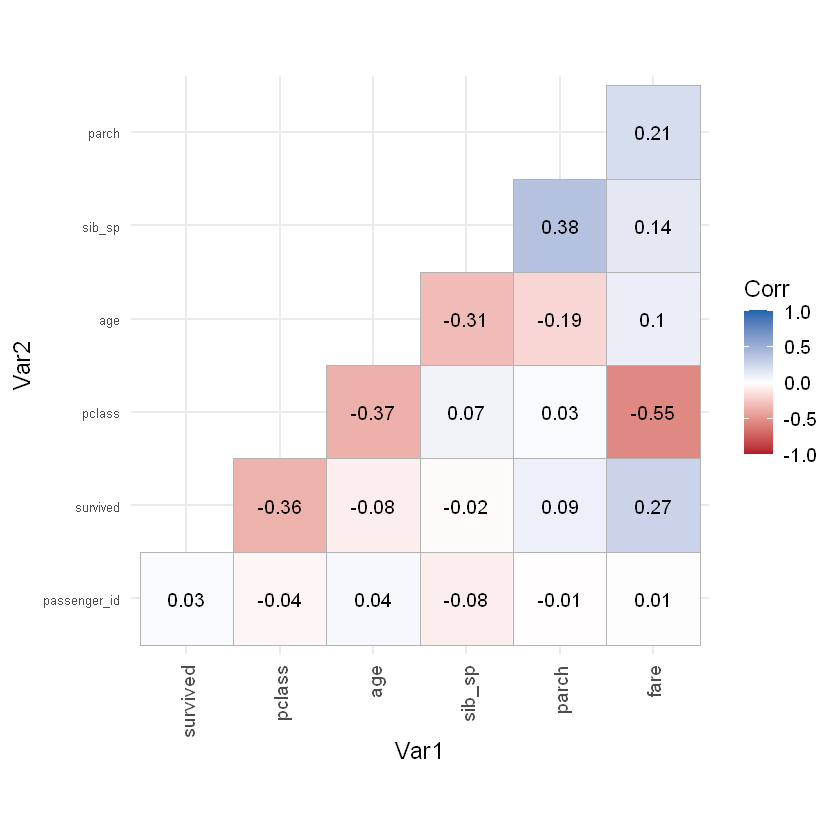

In [6]:
df_num <- df |>
  dplyr::select(where(is.numeric))

cor_matrix <- cor(
  df_num,
  use = "complete.obs",
  method = "pearson"
)

ggcorrplot(
  cor_matrix,
  type = "lower",
  lab = TRUE,
  lab_size = 4,
  colors = c("#b2182b", "white", "#2166ac"),
  outline.col = "gray70"
) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(
      angle = 90,
      hjust = 1,
      vjust = 0.5
    ),
    axis.text.y = element_text(size = 8)
  )

In [7]:
cat("Idades faltantes:", sum(is.na(df$age)), "\n")
idade_mediana <- median(df$age, na.rm = TRUE)

df <- df %>%
  mutate(age = ifelse(is.na(age), idade_mediana, age))

idade_mediana

Idades faltantes: 177 


[1] 28

In [8]:
cat("Embarque faltante:", sum(is.na(df$embarked)), "\n")

puerto_moda <- Mode(df$embarked, na.rm = TRUE)

df$embarked[is.na(df$embarked)] <- puerto_moda

Embarque faltante: 2 


In [9]:
df$HasCabin <- as.integer(!is.na(df$cabin))

df <- select(df, -cabin)

In [10]:
df <- df %>%
  mutate(fare = ifelse(is.na(fare), median(fare, na.rm = TRUE), fare))



df <- df %>%
  mutate(
    sex = ifelse(sex == "male", 0, 1),
    embarked = case_when(
      embarked == "S" ~ 0,
      embarked == "C" ~ 1,
      embarked == "Q" ~ 2
    )
  )


df <- df %>%
  select(-name, -ticket, -passenger_id)

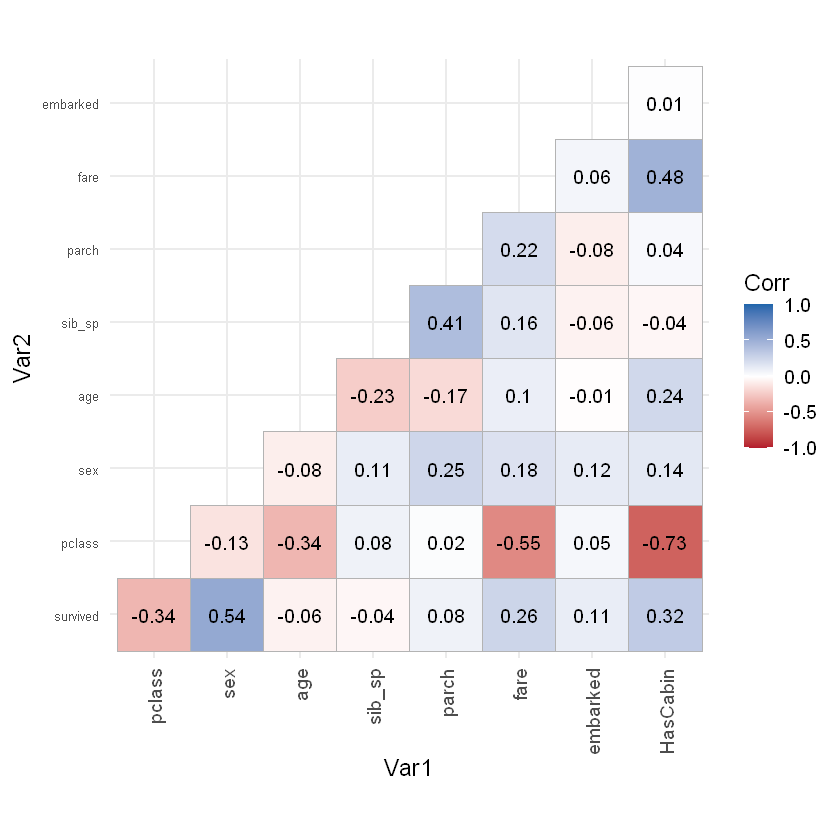

In [11]:
df_num <- df |>
  dplyr::select(where(is.numeric))

cor_matrix <- cor(
  df_num,
  use = "complete.obs",
  method = "pearson"
)

ggcorrplot(
  cor_matrix,
  type = "lower",
  lab = TRUE,
  lab_size = 4,
  colors = c("#b2182b", "white", "#2166ac"),
  outline.col = "gray70"
) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(
      angle = 90,
      hjust = 1,
      vjust = 0.5
    ),
    axis.text.y = element_text(size = 8)
  )

In [12]:
split <- initial_split(
  df,
  prop   = 0.75,
  strata = survived
)

train_data <- training(split)
test_data  <- testing(split)

In [13]:
train_data$survived <- as.factor(train_data$survived)

In [30]:
train_data$survived <- as.factor(train_data$survived)
test_data$survived  <- as.factor(test_data$survived)
train_data$survived <- factor(train_data$survived, levels = c("0", "1"))
test_data$survived  <- factor(test_data$survived, levels = c("0", "1"))

In [31]:
log_spec <- logistic_reg() |>
  set_engine("glm") |>
  set_mode("classification")

In [69]:
rec_all <- recipe(survived ~ ., data = train_data)

rec_no_sex <- recipe(survived ~ ., data = train_data) |>
  step_rm(sex)

rec_sex_only <- recipe(survived ~ sex, data = train_data)

In [70]:
wf_logit <- workflow_set(
  preproc = list(
    all_features = rec_all,
    no_sex       = rec_no_sex, 
    sex_only     = rec_sex_only
  ),
  models = list(
    logit = log_spec
  )
)

In [71]:
wf_fitted <- wf_logit %>%
  mutate(
    fit = purrr::map(
      info,
      ~ fit(.x$workflow[[1]], data = train_data)
    )
  )

In [72]:


pred_list <- wf_fitted$fit %>%
  map(~ bind_cols(
    predict(.x, test_data, type = "class"),
    predict(.x, test_data, type = "prob"),
    test_data
  ))

In [73]:
pred_all <- wf_fitted$wflow_id %>%
  map2(pred_list, ~ mutate(.y, model = .x)) %>%
  bind_rows()

In [74]:
metrics_class <- pred_all %>%
  group_by(model) %>%
  metric_set(
    accuracy,
    precision,
    recall
  )(
    truth = survived,
    estimate = .pred_class
  )

metrics_auc <- pred_all %>%
  group_by(model) %>%
  roc_auc(
    truth = survived,
    .pred_1,
    event_level = "second"
  )

In [75]:
metrics_final <- bind_rows(metrics_class, metrics_auc)
metrics_final

model,.metric,.estimator,.estimate
<chr>,<chr>,<chr>,<dbl>
all_features_logit,accuracy,binary,0.8214286
no_sex_logit,accuracy,binary,0.7455357
sex_only_logit,accuracy,binary,0.7991071
all_features_logit,precision,binary,0.8310811
no_sex_logit,precision,binary,0.7396450
sex_only_logit,precision,binary,0.8039216
all_features_logit,recall,binary,0.8913043
no_sex_logit,recall,binary,0.9057971
sex_only_logit,recall,binary,0.8913043


In [76]:
model_summary <- tibble(
  model = wf_fitted$wflow_id,
  summary = map(
    wf_fitted$fit,
    ~ summary(extract_fit_parsnip(.x)$fit)
  )
)
for (i in seq_len(nrow(model_summary))) {
  cat("\n============================\n")
  cat("Modelo:", model_summary$model[i], "\n")
  cat("============================\n\n")
  print(model_summary$summary[[i]])
}


Modelo: all_features_logit 


Call:
stats::glm(formula = ..y ~ ., family = stats::binomial, data = data)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)  1.6416012  0.5994780   2.738  0.00617 ** 
pclass      -0.9388130  0.1883676  -4.984 6.23e-07 ***
sex          2.7062567  0.2303986  11.746  < 2e-16 ***
age         -0.0373637  0.0089442  -4.177 2.95e-05 ***
sib_sp      -0.3370826  0.1254324  -2.687  0.00720 ** 
parch       -0.1517747  0.1331173  -1.140  0.25422    
fare         0.0005517  0.0026691   0.207  0.83626    
embarked     0.2337466  0.1639045   1.426  0.15384    
HasCabin     0.5176190  0.3360462   1.540  0.12348    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 888.31  on 666  degrees of freedom
Residual deviance: 592.93  on 658  degrees of freedom
AIC: 610.93

Number of Fisher Scoring iterations: 5


Modelo: no_sex_logit 


Call:
stats::glm(